###Часть 1 — Множественное выравнивание

Возьмем белок Dynamin-1 из 4х разных биологических видов: [proteinss.txt](https://drive.google.com/file/d/1J2WZoLLLz82zzPuZhULe7-sQuqD0An_i/view?usp=sharing)
*   Homo sapiens
*   Bos taurus
*   Rattus norvegicus
*   Drosophila melanogaster

Проведем множественное выравнивание при помощи MUSCLE и получим Newick формат выравнивания, по которому построим филогенетическое дерево.


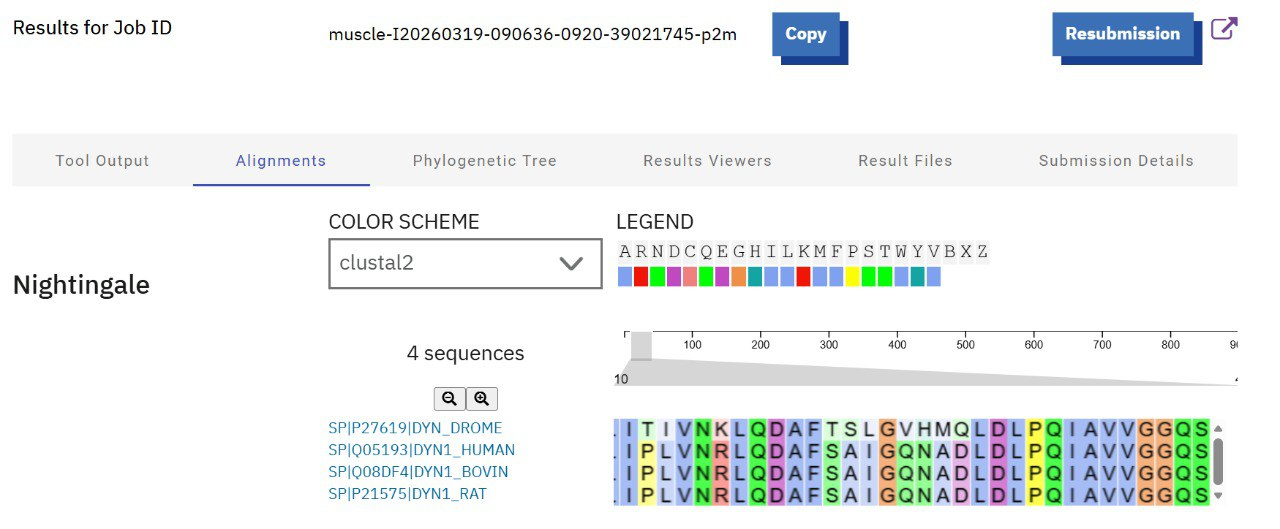

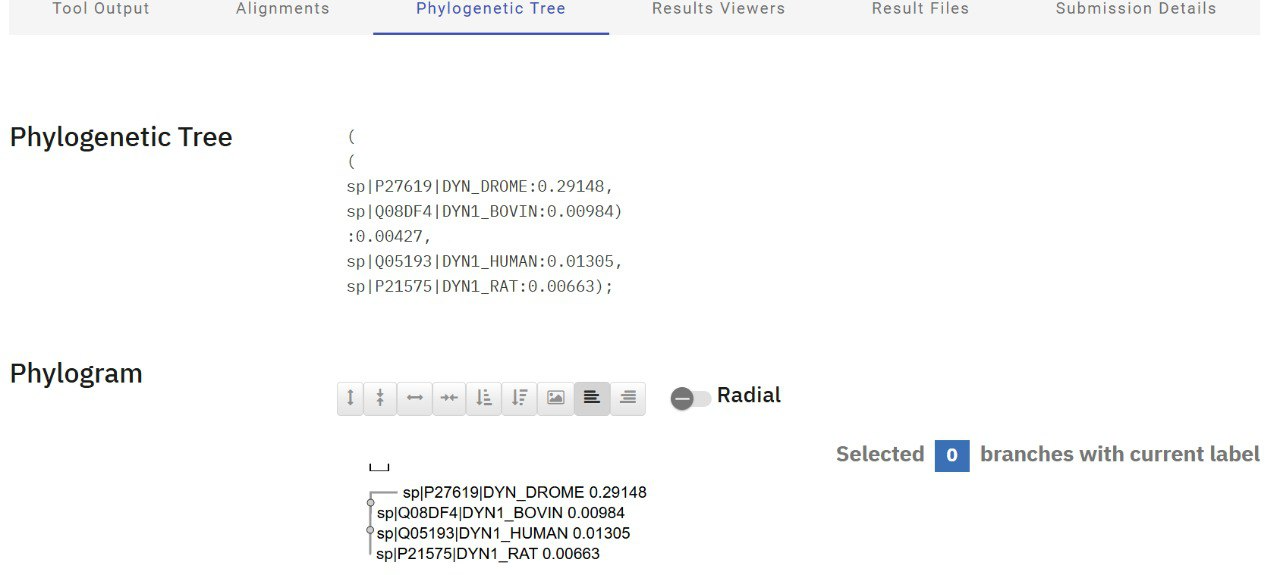

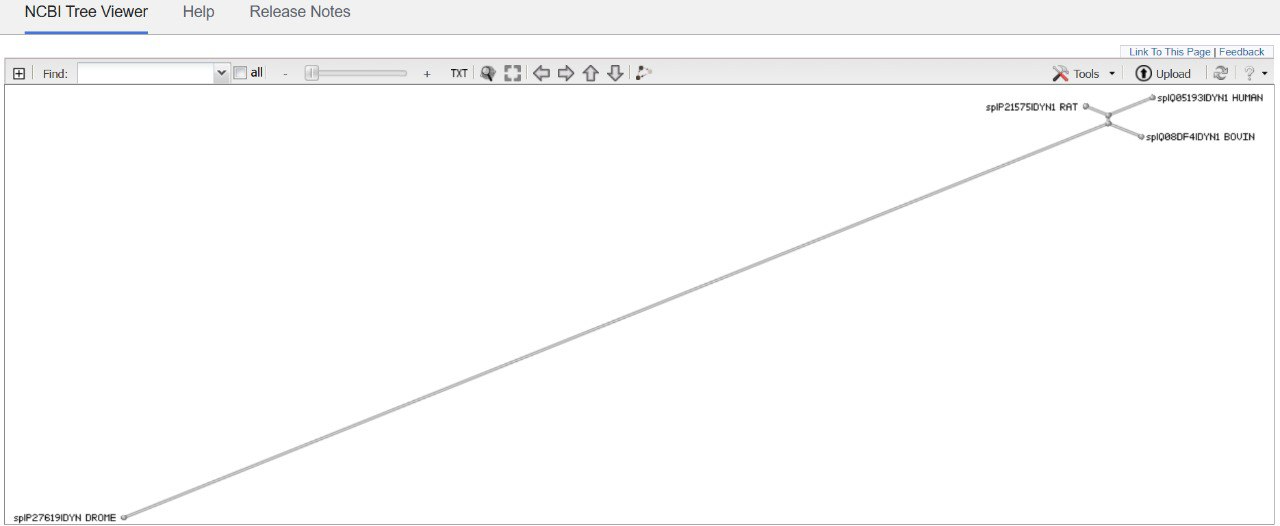

Мы видим, что млекопитающие отделились от насекомых, что и отражает длина ветви (еще интересно, что крыса и человек чуть ближе друг к другу, чем к корове)

###Часть 2 — MEGA и коронавирус

Для последовательностей Sars-CoV2 делаем множественное выравнивание и строим дерево

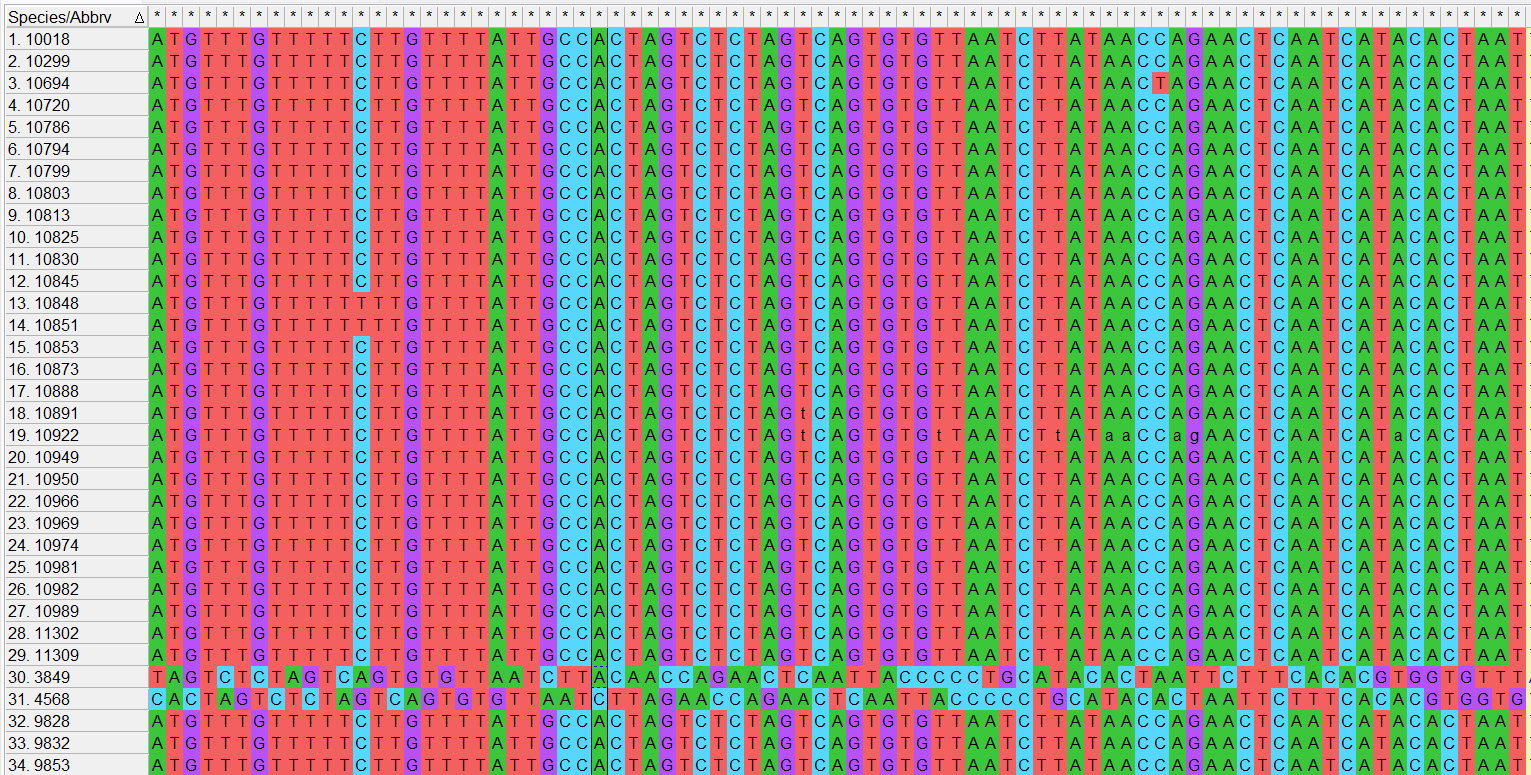

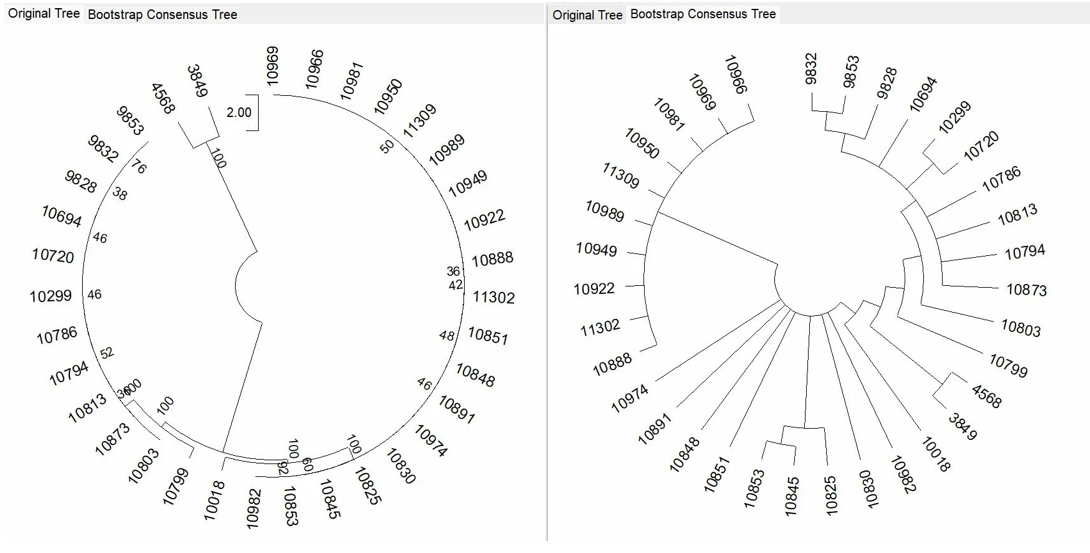

*   Образцы 4568 и 3849 заметно отличаются от остальных. У них другой паттерн цветов с самого начала последовательности. Это может указывать на другой вариант/штамм вируса (на дереве мы видим что  образцы 4568 и 3849 также выбиваются — они на отдельных ветвях, далеко от основного кластера)
*   Большинство образцов все же формируют один крупный кластер с высоким показателем уверенности на ветвях, что свидетельствует об их общем происхождении и принадлежности к одному доминирующему штамму

Добавим к анализу 3 последовательности, выявленые в штаммах территориально далеких от России (строки 35-37 США, Бразилия, Тайланд)

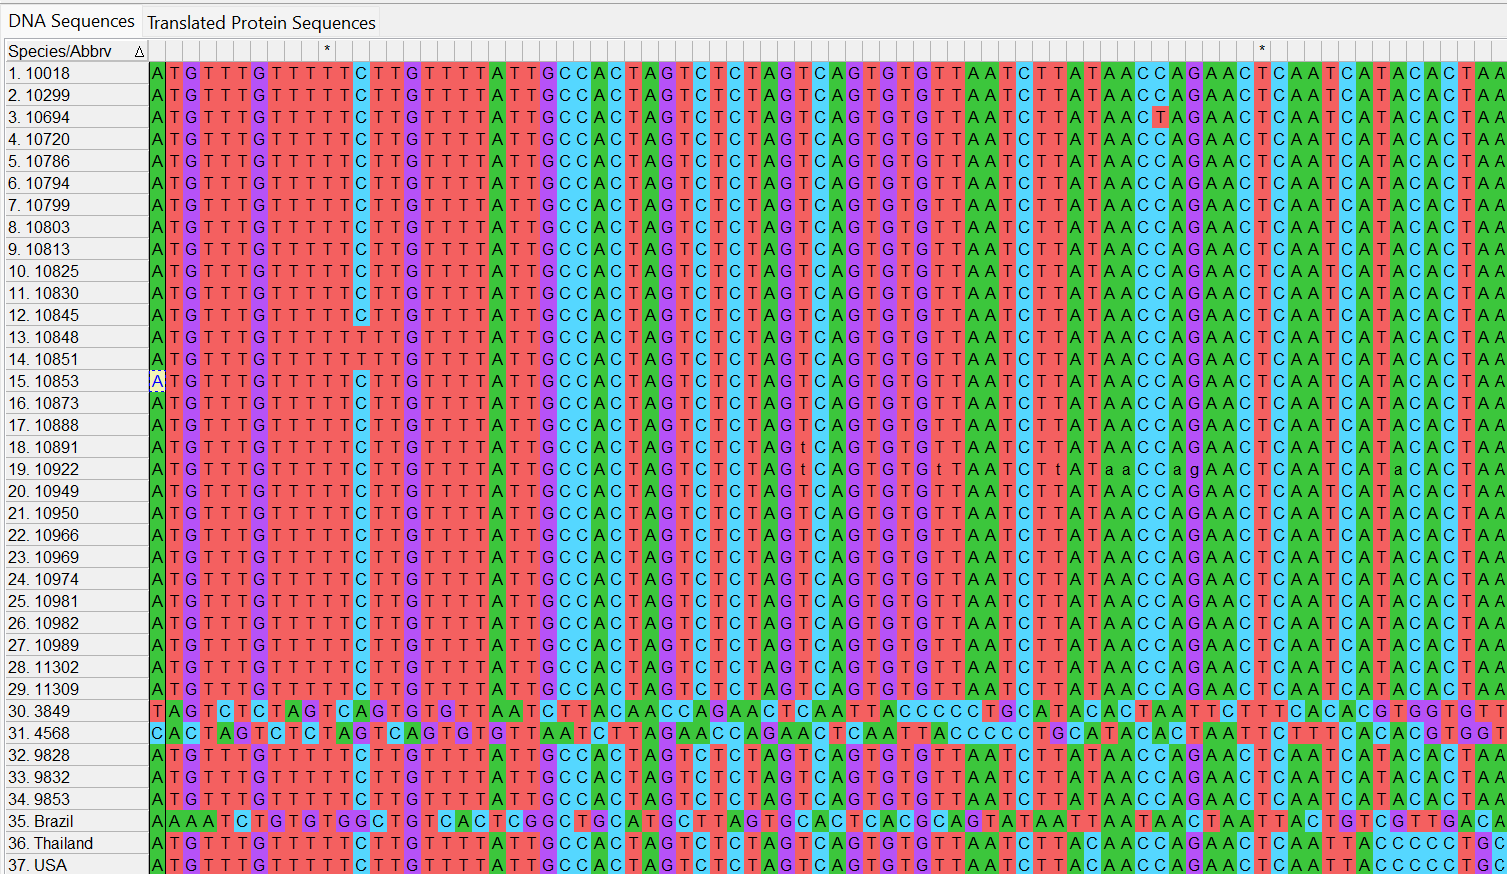

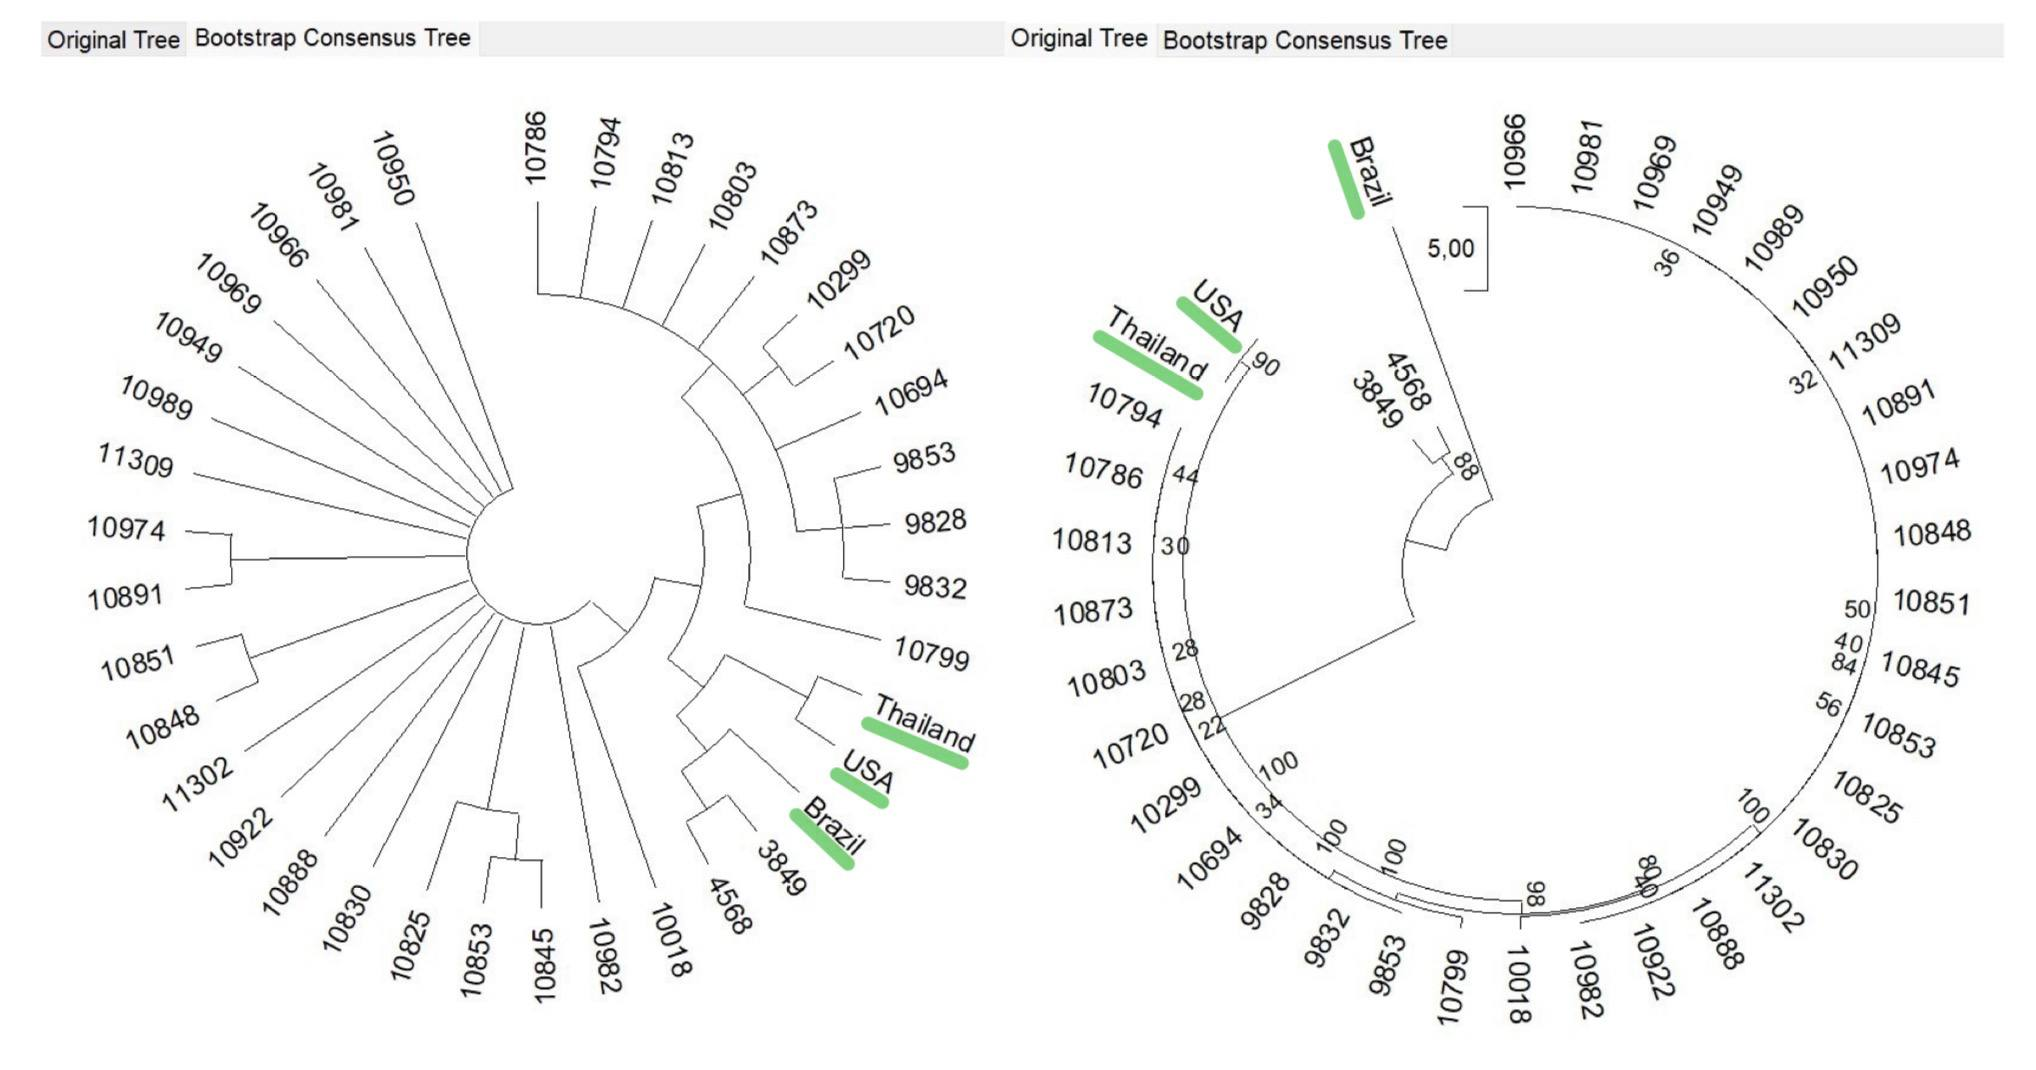

*   Brazil, USA и Thailand сгруппировались вместе в одном кластере, рядом с образцами 4568 и 3849, которые ещё в предыдущем анализе выбивались из основной российской группы (Bootstrap-результат — 90%, достаточно надежный)
*   Предположительно 4568 и 3849 группы как раз и являются завозными случаями в РФ
*   Также заметим, что Brazil располагается на отдельной ветви, изолированно от USA и Thailand + имеет отличный нуклеотидный состав

### Часть 3 — BLAST

**3.1**  Дана последовательность

>EGMQCSCGIDYYTPHEETNNESFVIYMFVVHFIIPLIVIFFCYGQLVFTVKEAAAQQQES


1) Поиск по NCBI BLAST дал однозначный результат - кодируется белок родопсин у крупного рогатого скота (Bos taurus и близкие виды)

2) Для поиска ортолога у человека используем blastp (тк он сравнивает на уровне аминокислот напрямую, что обеспечивает более высокую точность и скорость поиска) + используем базу nr (non-redundant protein sequence) с фильтром по человеку тк она уже содержит предсказанные и проверенные белки

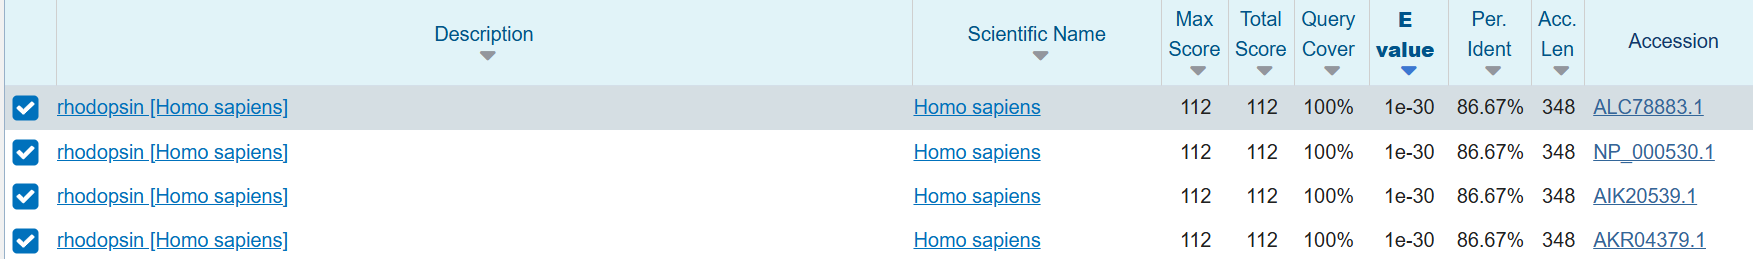

Ортолог родопсина есть. Мы видим, что E-value крайне мал, что говорит о невозможности случайного совпадения + довольно высокий процент идентичности (~86.7%)

3) Родопсин — светочувствительный белок находящийся в фоторецепторных клетках сетчатки глаза (в палочках). Отвечает за восприятие света, позволяя нам видеть при низкой освещенности.


Самый известный дефект, связанный с родопсином - «Куриная слепота» (человек с рождения не различает предметы в темноте, но цветовое и дневное зрение за счет колбочек может сохраняться)

**3.2**  В  базе NCBI Proteins найдем белковую последовательность для Luciola cruciata luciferase

Используем tblastn тк должны найти белковую посл-ть в транскриптоме (database - TSA, organism- Photinus pyralis)

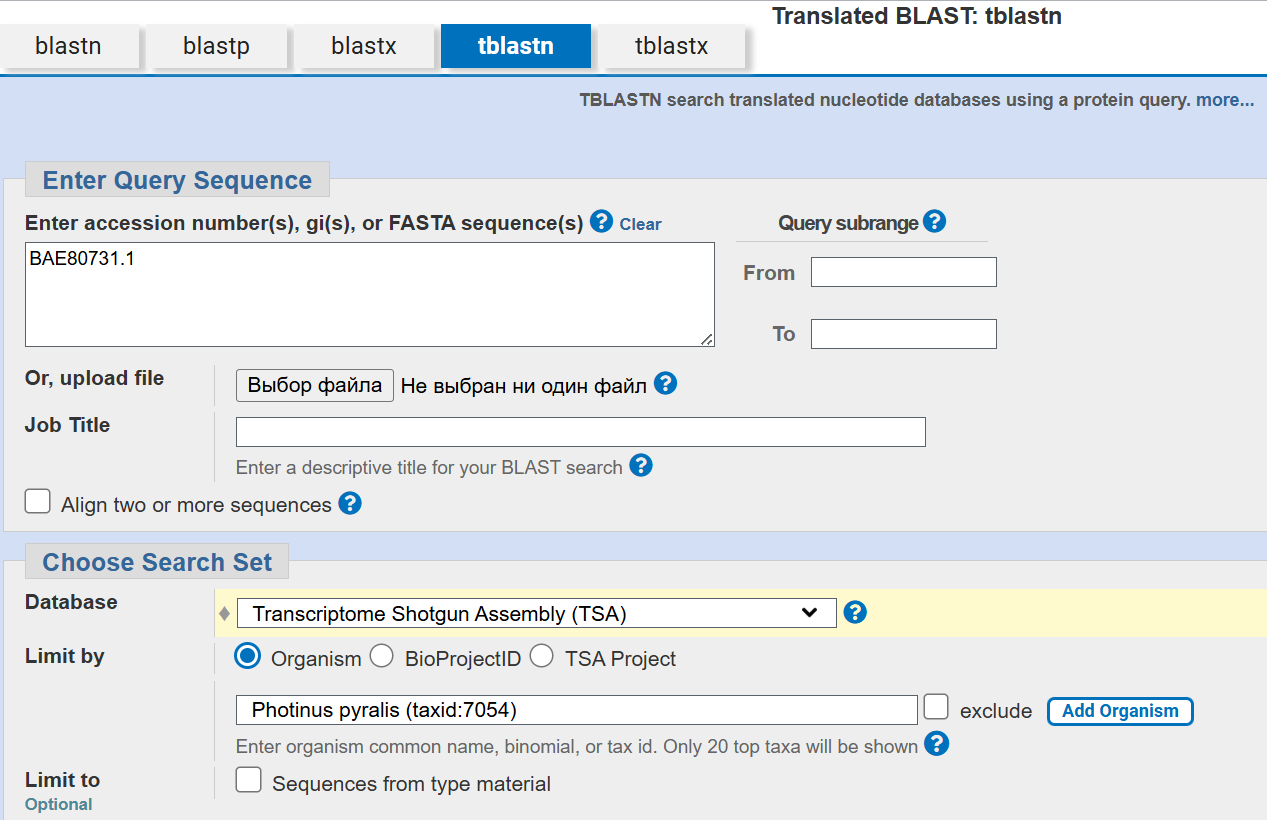

Получаем 10 полноразмерных транскриптов люцифераз с отличным E-value


Соберем их fasta-последовательности в один файл: [transcript.txt
](https://drive.google.com/file/d/1f18K_KjPJsJCCKIedb3az7JOhQmJziD_/view?usp=sharing)


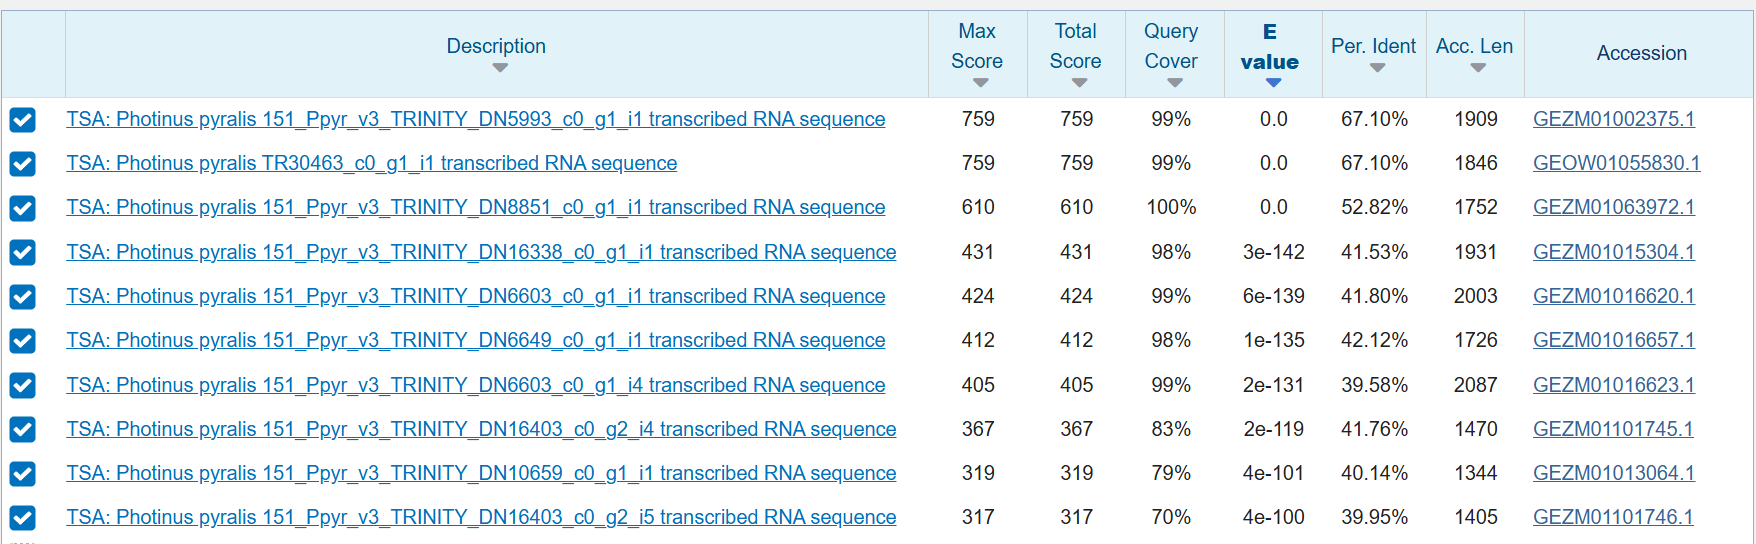

1)   Переведем транскрипты в белковые последовательности

In [ ]:
(base) bibizyana@LAPTOP-1QG8VVPK:~$ TransDecoder.LongOrfs -t transcript.fasta
(base) bibizyana@LAPTOP-1QG8VVPK:~$ head -20 transcript.fasta.transdecoder_dir/aa_seq.fasta
>GEZM01002375.1.p1 type:complete len:551 gc:universal GEZM01002375.1:111-1763(+)
MEDAKNIKKGPAPFYPLEDGTAGEQLHKAMKRYALVPGTIAFTDAHIEVNITYAEYFEMSVRLAEAMKRYGLNTNHRIVVCSENSLQFFMPVLGALFIGVAVAPANDIYNERELLNSMNISQPTVVFVSKKGLQKILNVQKKLPIIQKIIIMDSKTDYQGFQSMYTFVTSHLPPGFNEYDFVPESFDRDKTIALIMNSSGSTGLPKGVALPHRTACVRFSHARDPIFGNQIIPDTAILSVVPFHHGFGMFTTLGYLICGFRVVLMYRFEEELFLRSLQDYKIQSALLVPTLFSFFAKSTLIDKYDLSNLHEIASGGAPLSKEVGEAVAKRFHLPGIRQGYGLTETTSAILITPEGDDKPGAVGKVVPFFEAKVVDLDTGKTLGVNQRGELCVRGPMIMSGYVNNPEATNALIDKDGWLHSGDIAYWDEDEHFFIVDRLKSLIKYKGYQVAPAELESILLQHPNIFDAGVAGLPDDDAGELPAAVVVLEHGKTMTEKEIVDYVASQVTTAKKLRGGVVFVDEVPKGLTGKLDARKIREILIKAKKGGKSKL*
>GEOW01055830.1.p1 type:complete len:551 gc:universal GEOW01055830.1:47-1699(+)
MEDAKNIKKGPAPFYPLEDGTAGEQLHKAMKRYALVPGTIAFTDAHIEVNITYAEYFEMSVRLAEAMKRYGLNTNHRIVVCSENSLQFFMPVLGALFIGVAVAPANDIYNERELLNSMNISQPTVVFVSKKGLQKILNVQKKLPIIQKIIIMDSKTDYQGFQSMYTFVTSHLPPGFNEYDFVPESFDRDKTIALIMNSSGSTGLPKGVALPHRTACVRFSHARDPIFGNQIIPDTAILSVVPFHHGFGMFTTLGYLICGFRVVLMYRFEEELFLRSLQDYKIQSALLVPTLFSFFAKSTLIDKYDLSNLHEIASGGAPLSKEVGEAVAKRFHLPGIRQGYGLTETTSAILITPEGDDKPGAVGKVVPFFEAKVVDLDTGKTLGVNQRGELCVRGPMIMSGYVNNPEATNALIDKDGWLHSGDIAYWDEDEHFFIVDRLKSLIKYKGYQVAPAELESILLQHPNIFDAGVAGLPDDDAGELPAAVVVLEHGKTMTEKEIVDYVASQVTTAKKLRGGVVFVDEVPKGLTGKLDARKIREILIKAKKGGKSKL*

2)  Создадим базу данных BLAST

In [ ]:
(base) bibizyana@LAPTOP-1QG8VVPK:~$ makeblastdb -in aa_seq.fasta -dbtype prot -out database_

Building a new DB, current time: 03/27/2026 20:24:38
New DB name:   /home/bibizyana/database_
New DB title:  aa_seq.fasta
Sequence type: Protein

3,4.   Скачаем fasta-файл люциферазы и найдем 10 лучших совпадений по нашей базе данных

In [ ]:
(base) bibizyana@LAPTOP-1QG8VVPK:~$ blastp -query lucif_aa_seq.fasta -db database_ -out blast_results.txt -outfmt 6 -num_alignments 10
(base) bibizyana@LAPTOP-1QG8VVPK:~$ head -n 10 blast_results.txt
BAE80731.1      GEOW01055830.1.p1       68.577  541     169     1       4       543     1       541     0.0     783
BAE80731.1      GEZM01002375.1.p1       68.577  541     169     1       4       543     1       541     0.0     783
BAE80731.1      GEZM01063972.1.p1       54.098  549     250     2       1       548     11      558     0.0     629
BAE80731.1      GEZM01015304.1.p1       42.086  537     308     2       7       541     2       537     1.74e-155       446
BAE80731.1      GEZM01016620.1.p1       42.173  543     307     4       7       548     13      549     7.22e-151       435
BAE80731.1      GEZM01016657.1.p1       42.857  539     298     4       4       539     1       532     5.29e-147       425
BAE80731.1      GEZM01016623.1.p1       39.791  573     310     5       5       548     11      577     1.70e-143       417
BAE80731.1      GEZM01101745.1.p1       42.637  455     257     2       90      543     1       452     5.11e-130       378
BAE80731.1      GEZM01013064.1.p1       40.596  436     247     4       7       439     5       431     1.55e-110       327
BAE80731.1      GEZM01101746.1.p1       43.537  294     162     2       159     451     1       291     2.34e-82        250

5) Сохраним эти лучшие последовательности в новый fasta-файл

In [ ]:
(base) bibizyana@LAPTOP-1QG8VVPK:~$ awk '{print $2}' blast_results.txt | head -10 > top10_ids.txt  #лист с номерами белков
(base) bibizyana@LAPTOP-1QG8VVPK:~$ head -n 10 top10_ids.txt
GEOW01055830.1.p1
GEZM01002375.1.p1
GEZM01063972.1.p1
GEZM01015304.1.p1
GEZM01016620.1.p1
GEZM01016657.1.p1
GEZM01016623.1.p1
GEZM01101745.1.p1
GEZM01013064.1.p1
GEZM01101746.1.p1
(base) bibizyana@LAPTOP-1QG8VVPK:~$ seqtk subseq aa_seq.fasta top10_ids.txt > top10_aa_seq.fasta
(base) bibizyana@LAPTOP-1QG8VVPK:~$ head -n 10 top10_aa_seq.fasta
>GEZM01002375.1.p1 type:complete len:551 gc:universal GEZM01002375.1:111-1763(+)
MEDAKNIKKGPAPFYPLEDGTAGEQLHKAMKRYALVPGTIAFTDAHIEVNITYAEYFEMSVRLAEAMKRYGLNTNHRIVVCSENSLQFFMPVLGALFIGVAVAPANDIYNERELLNSMNISQPTVVFVSKKGLQKILNVQKKLPIIQKIIIMDSKTDYQGFQSMYTFVTSHLPPGFNEYDFVPESFDRDKTIALIMNSSGSTGLPKGVALPHRTACVRFSHARDPIFGNQIIPDTAILSVVPFHHGFGMFTTLGYLICGFRVVLMYRFEEELFLRSLQDYKIQSALLVPTLFSFFAKSTLIDKYDLSNLHEIASGGAPLSKEVGEAVAKRFHLPGIRQGYGLTETTSAILITPEGDDKPGAVGKVVPFFEAKVVDLDTGKTLGVNQRGELCVRGPMIMSGYVNNPEATNALIDKDGWLHSGDIAYWDEDEHFFIVDRLKSLIKYKGYQVAPAELESILLQHPNIFDAGVAGLPDDDAGELPAAVVVLEHGKTMTEKEIVDYVASQVTTAKKLRGGVVFVDEVPKGLTGKLDARKIREILIKAKKGGKSKL*
>GEOW01055830.1.p1 type:complete len:551 gc:universal GEOW01055830.1:47-1699(+)
MEDAKNIKKGPAPFYPLEDGTAGEQLHKAMKRYALVPGTIAFTDAHIEVNITYAEYFEMSVRLAEAMKRYGLNTNHRIVVCSENSLQFFMPVLGALFIGVAVAPANDIYNERELLNSMNISQPTVVFVSKKGLQKILNVQKKLPIIQKIIIMDSKTDYQGFQSMYTFVTSHLPPGFNEYDFVPESFDRDKTIALIMNSSGSTGLPKGVALPHRTACVRFSHARDPIFGNQIIPDTAILSVVPFHHGFGMFTTLGYLICGFRVVLMYRFEEELFLRSLQDYKIQSALLVPTLFSFFAKSTLIDKYDLSNLHEIASGGAPLSKEVGEAVAKRFHLPGIRQGYGLTETTSAILITPEGDDKPGAVGKVVPFFEAKVVDLDTGKTLGVNQRGELCVRGPMIMSGYVNNPEATNALIDKDGWLHSGDIAYWDEDEHFFIVDRLKSLIKYKGYQVAPAELESILLQHPNIFDAGVAGLPDDDAGELPAAVVVLEHGKTMTEKEIVDYVASQVTTAKKLRGGVVFVDEVPKGLTGKLDARKIREILIKAKKGGKSKL*